# S6 — Bonus: hands-on with a public dataset (GSE106118)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S6_Bonus_GSE106118.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

Everything so far used data we prepared for you. This notebook takes a dataset
straight from a public repository and walks the whole way from raw file to
biological result.

**GSE106118** is a *single-cell* RNA-seq dataset from human embryonic heart
(Cui et al., *Cell Reports* 2019). The file we use here, `HE10W`, holds 193
individual cells from a 10-week embryo, each belonging to one of the four
chambers: left atrium (LA), right atrium (RA), left ventricle (LV), right
ventricle (RV). We ask which genes distinguish the chambers.

> **Why a single-cell dataset in a bulk course?** Because the file looks exactly
> like a bulk matrix — genes down the rows, one column per column — and telling
> the difference is a skill worth having. Two consequences run through the whole
> notebook: the matrix is **sparse** (most entries are zero, which is a property
> of the technology, not of the biology), and the columns are **cells, not
> biological replicates**. Section 5 aggregates cells into *pseudo-bulk* profiles
> before making any chamber-level statement, and section 8 is explicit about how
> far the statistics actually reach.

You will practise: parsing a real file, deriving metadata from column names, QC,
filtering, transformation, pseudo-bulk aggregation, correlation, group
comparison, and exporting a multi-sheet Excel report.

## 0. Setup

In [49]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "pandas", "numpy", "seaborn", "scipy", "statsmodels", "openpyxl", "session-info"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/data/"


def data_path(fname):
    local = Path("../data") / fname
    return local if local.exists() else RAW + fname


OUT = Path("../results/py")
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Read the data

The file is gzip-compressed. pandas decompresses it automatically from the
`.gz` extension — no unzipping, and no helper function needed.

> The R lesson writes a small `read_expr()` function to dispatch on the file
> extension. `pd.read_csv` already does that for you.

In [50]:
raw_df = pd.read_csv(data_path("GSE106118_HE10W.tsv.gz"), sep="\t")

print(f"{raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"first columns: {list(raw_df.columns[:6])}")
raw_df.iloc[:5, :6]

24,153 rows x 194 columns
first columns: ['Gene', 'LA1', 'LA2', 'LA3', 'LA4', 'LA5']


,Gene,LA1,LA2,LA3,LA4,LA5
0,A1BG,0.0,0.0,0.0,0.0,0.0
1,A1BG-AS1,0.0,0.0,0.0,0.0,0.0
2,A1CF,0.0,0.0,0.0,0.0,0.0
3,A2M,0.0,0.0,0.0,0.0,0.0
4,A2M-AS1,0.0,0.0,0.0,0.0,0.0


### 1.1 Clean the column names

Files that have been through a spreadsheet often pick up stray whitespace in
their headers. Strip it before anything else — a trailing space in a column name
causes errors that are very hard to spot.

In [51]:
before = list(raw_df.columns[:3])
raw_df.columns = (
    raw_df.columns.str.replace(r"\s+", "", regex=True)
    .str.replace(r"\.+", ".", regex=True)
)
print(f"before: {before}")
print(f"after : {list(raw_df.columns[:3])}")

assert "Gene" in raw_df.columns, "expected a 'Gene' column"

before: ['Gene', 'LA1', 'LA2']
after : ['Gene', 'LA1', 'LA2']


### 1.2 Build the expression matrix

Genes as rows, cells as columns. Duplicate gene symbols would break the index,
so we drop them first.

In [ ]:
dupes = raw_df["Gene"].duplicated().sum()
print(f"duplicated gene names: {dupes}")

expr = (
    raw_df.drop_duplicates(subset="Gene")
    .set_index("Gene")
    .apply(pd.to_numeric, errors="coerce")
)

print(f"expression matrix: {expr.shape[0]:,} genes x {expr.shape[1]} cells")
print(f"missing values   : {expr.isna().sum().sum():,}")
print(f"zero entries     : {(expr == 0).to_numpy().mean():.1%} of the matrix")
expr.iloc[:3, :6]

## 2. Derive the cell metadata

There is no samplesheet — the design is encoded in the column names
(`LA1`, `LA2`, `RV7`, …). Extracting it with a regular expression is a very
common real-world task.

In [ ]:
cells = pd.Series(expr.columns, name="cell")

meta = pd.DataFrame({
    "cell": cells,
    "chamber": cells.str.extract(r"^([A-Z]{2})", expand=False),
    # The trailing number just indexes cells within a chamber. It is NOT a
    # biological replicate — every cell in this file comes from one embryo.
    "cell_number": pd.to_numeric(cells.str.extract(r"(\d+)", expand=False)),
}).set_index("cell")

print(meta["chamber"].value_counts().sort_index())
print(f"\nany cell we failed to parse? {meta['chamber'].isna().sum()}")
meta.head()

Give the chambers a sensible order so that every figure below is consistent:
atria first, then ventricles; left before right.

In [54]:
CHAMBERS = ["LA", "RA", "LV", "RV"]
meta["chamber"] = pd.Categorical(meta["chamber"], categories=CHAMBERS, ordered=True)
PALETTE = dict(zip(CHAMBERS, sns.color_palette("Set2", 4)))
print(f"chamber order: {CHAMBERS}")

chamber order: ['LA', 'RA', 'LV', 'RV']


## 3. Quality control

The obvious check on an expression matrix is the total signal per column. Here it
tells you nothing: TPM is normalised *within* each column, so every column sums to
one million by construction. We print the range below to make the point — it is a
useful habit to ask what a QC metric could possibly reveal before trusting it.

The check that does work on this data is **how many genes each cell detects**.
A column that detects almost nothing is a failed cell rather than a quiet one, and
removing it is the most common QC step in single-cell work.

In [ ]:
qc = meta.copy()
qc["tpm_sum"] = expr.sum(axis=0)
qc["genes_detected"] = (expr > 0).sum(axis=0)

# Why the usual QC plot is useless here: TPM is per-column normalised.
print(f"total TPM per cell: min {qc['tpm_sum'].min():,.0f}, "
      f"max {qc['tpm_sum'].max():,.0f}  <- normalised by construction")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=qc, x="chamber", y="genes_detected", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=qc, x="chamber", y="genes_detected", order=CHAMBERS,
              color="black", size=3, alpha=0.5, ax=ax)
ax.set(title="Genes detected per cell, by chamber", xlabel="Chamber",
       ylabel="Genes with TPM > 0")
plt.tight_layout()
plt.show()

print(qc.groupby("chamber", observed=True)["genes_detected"].describe().round(0))

# A cell detecting almost nothing is a failure, not a measurement.
MIN_GENES = 500
low = qc.loc[qc["genes_detected"] < MIN_GENES, ["chamber", "genes_detected"]]
print(f"\ncells detecting fewer than {MIN_GENES} genes: {len(low)}")
print(low.to_string())

## 4. Filter and transform

### 4.1 Drop genes that are essentially absent

Keep a gene if it exceeds 1 TPM in at least 2 cells.

In [56]:
keep = (expr > 1).sum(axis=1) >= 2

print(f"genes before : {len(keep):,}")
print(f"genes removed: {(~keep).sum():,}")
print(f"genes kept   : {keep.sum():,}")

expr_f = expr.loc[keep]

genes before : 24,153
genes removed: 7,243
genes kept   : 16,910


### 4.2 log1p

Expression data spans several orders of magnitude. `log1p(x)` computes
`log(1 + x)`, which handles zeros gracefully — `log(0)` is undefined, but
`log1p(0)` is 0.

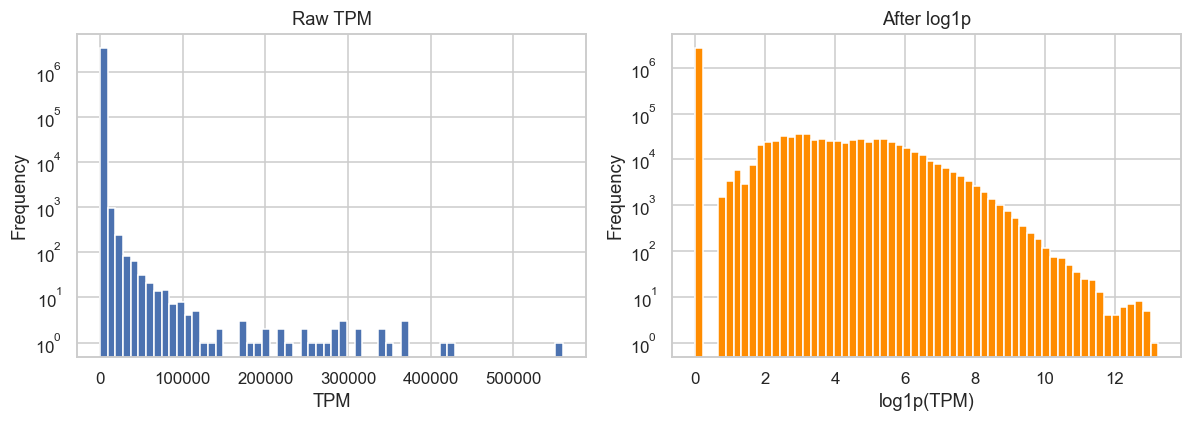

In [57]:
log_tpm = np.log1p(expr_f)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(expr_f.values.flatten(), bins=60)
axes[0].set(title="Raw TPM", xlabel="TPM", ylabel="Frequency", yscale="log")
axes[1].hist(log_tpm.values.flatten(), bins=60, color="darkorange")
axes[1].set(title="After log1p", xlabel="log1p(TPM)", ylabel="Frequency", yscale="log")
plt.tight_layout()
plt.show()

### 4.3 The most highly expressed genes

In [58]:
top10 = log_tpm.mean(axis=1).nlargest(10)
print("top 10 genes by mean expression:")
print(top10.round(3))

top 10 genes by mean expression:
Gene
MYL7      9.352
FTH1      8.652
ACTC1     8.520
EEF1A1    8.471
TPM1      8.431
MYL6      8.309
RPLP1     8.271
GAPDH     8.250
TMSB10    8.194
HSPB1     8.181
dtype: float64


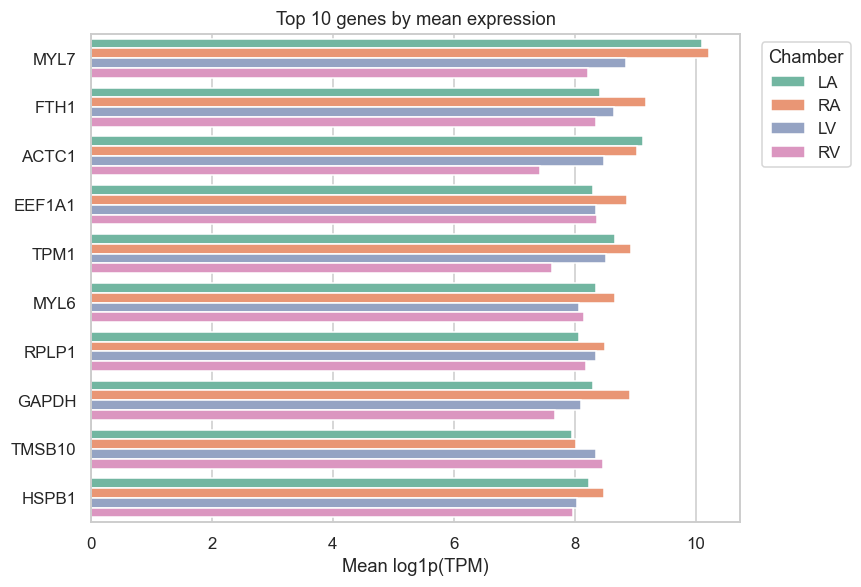

In [59]:
top_long = (
    log_tpm.loc[top10.index]
    .T.join(meta["chamber"])
    .melt(id_vars="chamber", var_name="Gene", value_name="log1p_tpm")
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=top_long, y="Gene", x="log1p_tpm", hue="chamber",
            order=top10.index, hue_order=CHAMBERS, palette=PALETTE,
            errorbar=None, ax=ax)
ax.set(title="Top 10 genes by mean expression", xlabel="Mean log1p(TPM)", ylabel="")
ax.legend(title="Chamber", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Look at what came out. `MYL7`, `ACTC1`, `TPM1` and `MYL6` are sarcomeric — the
contractile machinery of cardiac muscle. `EEF1A1`, `GAPDH`, `TMSB10` and `RPLP1`
are housekeeping and ribosomal genes, which are abundant in any tissue. `FTH1`
stores iron and `HSPB1` is a heat-shock protein enriched in muscle.

That mix is exactly what heart tissue should look like, and it is a good sign
the data is what it claims to be. Checking that the top-expressed genes make
biological sense is a quick, cheap sanity check worth doing on any new dataset.

## 5. Pseudo-bulk: chamber-averaged expression and correlation

From here on we stop working with individual cells and average each gene within
each chamber. That aggregate is a **pseudo-bulk** profile, and it is the honest
unit for any chamber-level claim.

The reason is that the 193 cells are not 193 independent observations. They come
from one embryo, so they share everything about it — its genotype, its
developmental stage, how the tissue was handled. Treating them as independent
would let the number of *cells* stand in for the number of *hearts*, which is not
what a chamber-level question is asking. Averaging to one profile per chamber
removes that temptation, and as a bonus it cancels much of the per-cell dropout
you saw in section 3.

With that done, we ask how similar the four chamber profiles are to each other.

In [60]:
chamber_means = log_tpm.T.join(meta["chamber"]).groupby("chamber", observed=True).mean().T
chamber_means = chamber_means[CHAMBERS]
# The transpose + groupby drops the index name; restore it so that later
# .reset_index() calls produce a column called "Gene" rather than "index".
chamber_means.index.name = "Gene"
chamber_means.columns.name = None

print(f"gene x chamber matrix: {chamber_means.shape}")
chamber_means.head(3).round(3)

gene x chamber matrix: (16910, 4)


,LA,RA,LV,RV
Gene,,,,
A1BG-AS1,0.526,0.293,0.000,0.000
A2M,1.323,0.000,0.181,0.460
A2M-AS1,0.000,0.131,0.000,0.244


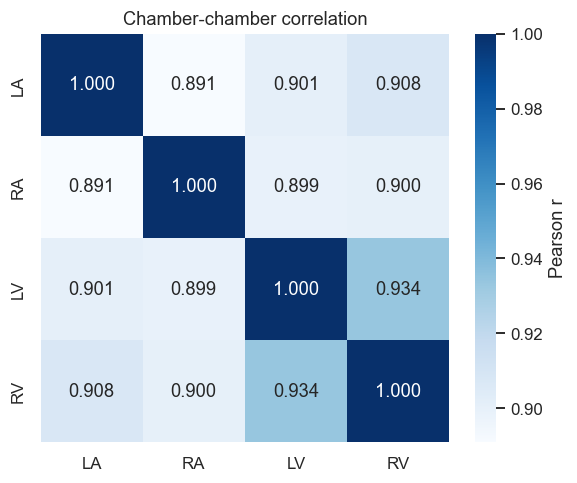

All four chambers are highly correlated — they are all heart muscle.
The interesting signal is in the small differences, not the big similarity.


In [61]:
corr = chamber_means.corr(method="pearson")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr.values.min(), vmax=1.0,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set(title="Chamber-chamber correlation")
plt.tight_layout()
plt.show()

print("All four chambers are highly correlated — they are all heart muscle.")
print("The interesting signal is in the small differences, not the big similarity.")

## 6. Chamber-biased genes

Now the biology. We contrast the two atria against each other, and the two
ventricles against each other, by subtracting the mean expression.

In [62]:
contrasts = {
    "LA vs RA (atria)": ("LA", "RA"),
    "LV vs RV (ventricles)": ("LV", "RV"),
}

biased = {}
for title, (a, b) in contrasts.items():
    d = pd.DataFrame({
        a: chamber_means[a],
        b: chamber_means[b],
        "delta": chamber_means[a] - chamber_means[b],
    })
    d["abs_delta"] = d["delta"].abs()
    biased[title] = d.sort_values("abs_delta", ascending=False)
    print(f"\n--- {title}: 10 most biased genes ---")
    print(biased[title].head(10)[[a, b, "delta"]].round(3))


--- LA vs RA (atria): 10 most biased genes ---
                 LA     RA  delta
Gene                             
ABCC9         6.611  2.919  3.692
L2HGDH        5.497  1.845  3.652
LOC100129434  6.243  2.901  3.342
LOC102724699  6.765  3.448  3.317
INMT          4.758  1.484  3.274
PARP15        5.663  2.422  3.241
ORC4          5.234  2.064  3.169
METTL21A      6.476  3.311  3.165
FOXK1         6.914  3.786  3.128
MYH7          1.547  4.615 -3.068

--- LV vs RV (ventricles): 10 most biased genes ---
          LV     RV  delta
Gene                      
LYZ    6.160  1.749  4.411
MPO    5.230  0.951  4.279
SPP1   1.172  4.695 -3.523
CCL4   0.337  3.078 -2.741
CCL3   0.472  3.086 -2.614
CXCL8  1.218  3.831 -2.613
MT3    3.722  1.156  2.566
IL1B   0.485  3.045 -2.560
PLAC8  2.759  0.365  2.394
RRM2   3.025  0.640  2.385


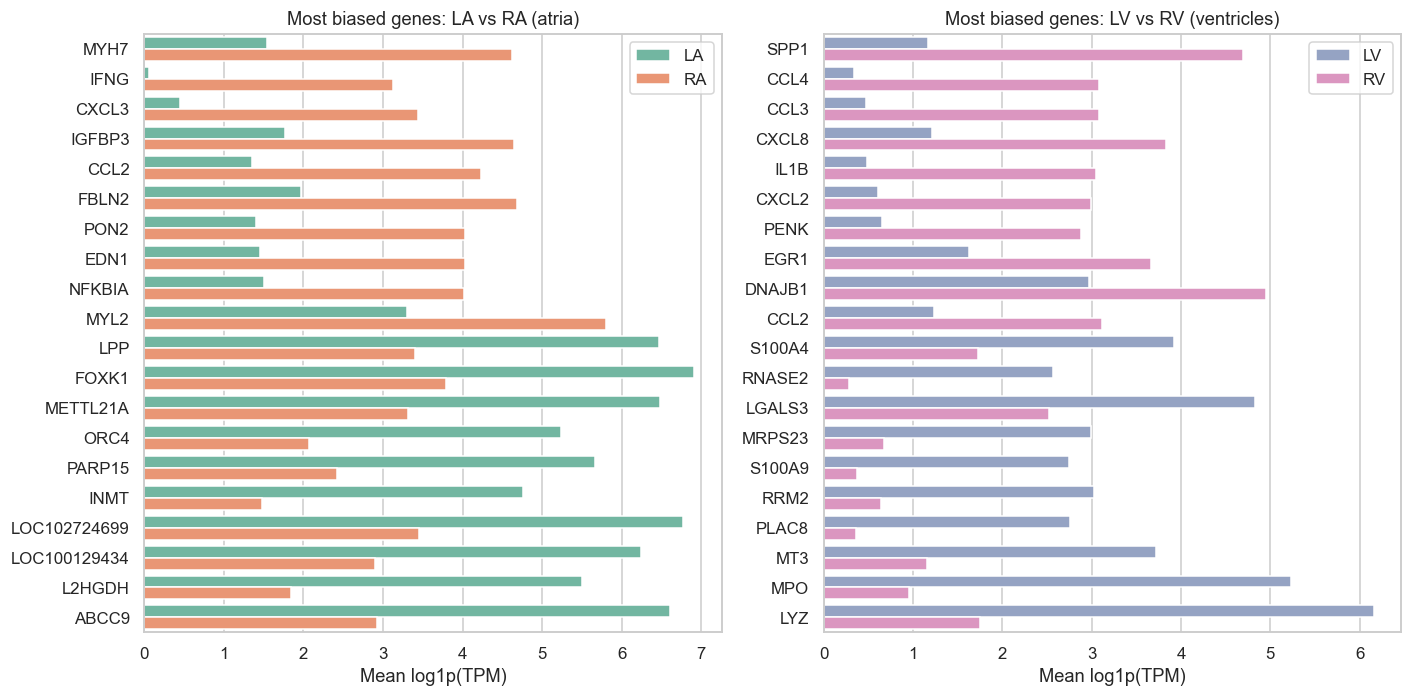

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

for ax, (title, (a, b)) in zip(axes, contrasts.items()):
    d = biased[title]
    top = pd.concat([d.nlargest(10, "delta"), d.nsmallest(10, "delta")])
    plot_df = (
        top[[a, b]].reset_index()
        .melt(id_vars="Gene", var_name="chamber", value_name="mean_log1p")
    )
    order = top.sort_values("delta").index
    sns.barplot(data=plot_df, y="Gene", x="mean_log1p", hue="chamber",
                order=order, palette=PALETTE, ax=ax)
    ax.set(title=f"Most biased genes: {title}", xlabel="Mean log1p(TPM)", ylabel="")
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 7. A single gene across all four chambers

`NOTCH1` is essential for cardiac development and is mutated in several forms of
congenital heart disease — the same disease family as the CHD gene list in S3.

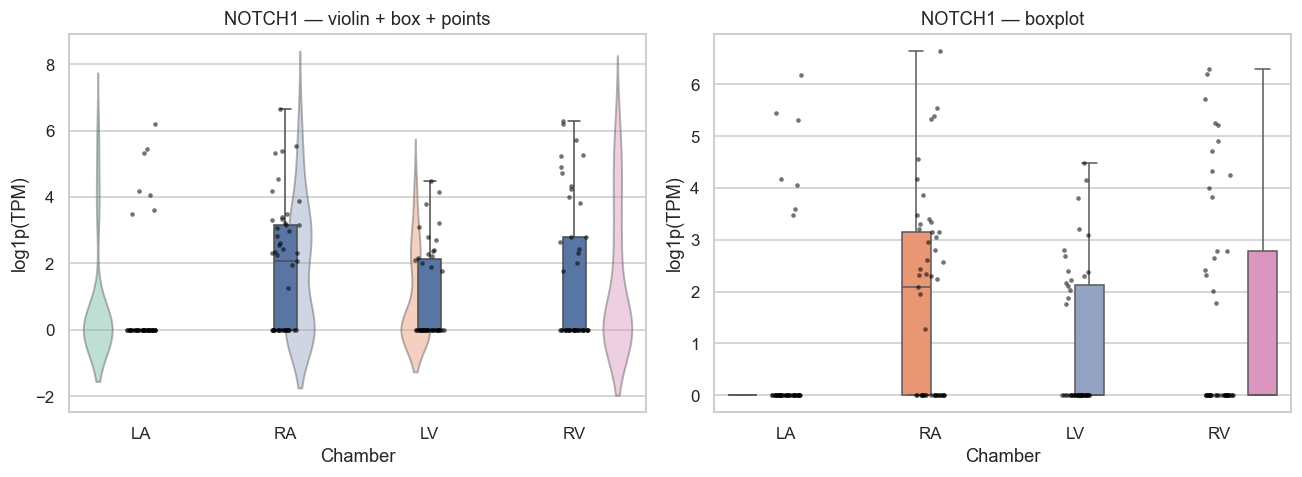

         count   mean    std  min  25%    50%    75%    max
chamber                                                    
LA        48.0  0.672  1.686  0.0  0.0  0.000  0.000  6.184
RA        49.0  1.827  1.905  0.0  0.0  2.083  3.151  6.646
LV        48.0  0.905  1.374  0.0  0.0  0.000  2.118  4.475
RV        48.0  1.488  2.133  0.0  0.0  0.000  2.782  6.291


In [64]:
GENE = "NOTCH1"
assert GENE in log_tpm.index, f"{GENE} not found"

gene_df = meta.copy()
gene_df["expression"] = log_tpm.loc[GENE]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.violinplot(data=gene_df, x="chamber", y="expression", hue="chamber",
               order=CHAMBERS, palette=PALETTE, legend=False,
               inner=None, alpha=0.45, ax=axes[0])
sns.boxplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
            width=0.16, showfliers=False, boxprops={"zorder": 2}, ax=axes[0])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[0])
axes[0].set(title=f"{GENE} — violin + box + points", xlabel="Chamber",
            ylabel="log1p(TPM)")

sns.boxplot(data=gene_df, x="chamber", y="expression", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False,
            showfliers=False, ax=axes[1])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[1])
axes[1].set(title=f"{GENE} — boxplot", xlabel="Chamber", ylabel="log1p(TPM)")

plt.tight_layout()
plt.show()

print(gene_df.groupby("chamber", observed=True)["expression"].describe().round(3))

## 8. Pairwise statistical comparison

The question has to be stated carefully here, because the answer depends on it.

We are comparing **cells within one embryo**: do the LA cells and the LV cells of
*this heart* differ in NOTCH1 expression? That is a legitimate question, and the
Mann-Whitney below answers it correctly with n = 48 and 49 cells.

What it does not answer is whether the left atrium differs from the left ventricle
*in humans*. For that the unit of replication is the embryo, and we have one. No
test on 193 cells from a single heart can widen the claim, however small the
p-value gets.

> **The replication ladder: cells → embryo → population.** A test is valid at the
> level whose units it actually resamples. Every rung up the ladder needs new
> units, not more measurements of the units you already have. Treating cells as
> biological replicates — *pseudoreplication* — is one of the most common errors
> in genomics, and it makes p-values look far smaller than the evidence supports.
> When you read `n1 = 48` below, read it as *48 cells*, not *48 hearts*.

Six pairwise comparisons between four chambers still means six chances of a false
positive, so we correct with Benjamini-Hochberg. That part is independent of which
rung of the ladder you are standing on.

> R does this in one call: `pairwise.wilcox.test(..., p.adjust.method = "BH")`.
> Python needs two steps — the tests, then the correction — which makes the
> multiple-testing step visible instead of hidden in a default argument.

In [65]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(CHAMBERS, 2):
    x = gene_df.loc[gene_df["chamber"] == a, "expression"]
    y = gene_df.loc[gene_df["chamber"] == b, "expression"]
    u = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({
        "group1": a, "group2": b,
        "n1": len(x), "n2": len(y),
        "median1": x.median(), "median2": y.median(),
        "U": u.statistic, "p_raw": u.pvalue,
    })

pw = pd.DataFrame(rows)
pw["p_adj"] = multipletests(pw["p_raw"], method="fdr_bh")[1]
pw["significant"] = pw["p_adj"] < 0.05
pw = pw.sort_values("p_adj").reset_index(drop=True)

print(f"pairwise comparisons of {GENE} expression (BH-corrected):")
print(pw.round(4).to_string(index=False))

pairwise comparisons of NOTCH1 expression (BH-corrected):
group1 group2  n1  n2  median1  median2      U  p_raw  p_adj  significant
    LA     RA  48  49   0.0000   2.0832  762.0 0.0005 0.0028         True
    RA     LV  49  48   2.0832   0.0000 1506.0 0.0090 0.0269         True
    LA     RV  48  48   0.0000   0.0000  903.0 0.0183 0.0366         True
    LA     LV  48  48   0.0000   0.0000  983.0 0.0991 0.1486        False
    RA     RV  49  48   2.0832   0.0000 1325.0 0.2440 0.2928        False
    LV     RV  48  48   0.0000   0.0000 1030.0 0.2976 0.2976        False


## 9. Export a report

Top 50 genes per chamber, one worksheet per chamber — the equivalent of the R
lesson's `openxlsx` workbook loop.

In [66]:
TOP_N = 50
report_file = OUT / "TopGenes_perChamber.xlsx"

with pd.ExcelWriter(report_file, engine="openpyxl") as writer:
    for chamber in CHAMBERS:
        top = (
            chamber_means[chamber]
            .nlargest(TOP_N)
            .rename("mean_log1p_tpm")
            .reset_index()
        )
        top.insert(0, "rank", range(1, len(top) + 1))
        top.to_excel(writer, sheet_name=chamber, index=False)

print(f"wrote {report_file} ({report_file.stat().st_size:,} bytes)")

check = pd.read_excel(report_file, sheet_name=None)
print(f"sheets written: {list(check.keys())}")
print(f"rows per sheet: {[len(v) for v in check.values()]}")
print("\nLA sheet, first rows:")
print(check["LA"].head().round(3))

wrote ../results/py/TopGenes_perChamber.xlsx (12,319 bytes)
sheets written: ['LA', 'RA', 'LV', 'RV']
rows per sheet: [50, 50, 50, 50]

LA sheet, first rows:
   rank   Gene  mean_log1p_tpm
0     1   MYL7          10.105
1     2  ACTC1           9.130
2     3   NPPA           8.841
3     4   TPM1           8.657
4     5   FTH1           8.417


> **On output paths.** We write to `results/py/`, a fixed location relative to
> this notebook. The R version of this lesson used `getwd()`, which meant the
> file landed wherever the notebook happened to be run from — and in practice
> ended up written to two different folders. Always anchor your output paths.

## 10. Where to go next: functional enrichment

You now have a ranked gene list per chamber. The obvious next question is what
those genes *do*.

Paste one of the exported sheets into **Enrichr** (<https://maayanlab.cloud/Enrichr/>)
to test it against GO terms, pathways and disease annotations.

To do it in Python instead, `gseapy` wraps the same service:

```python
# pip install gseapy
import gseapy as gp
enr = gp.enrichr(
    gene_list=chamber_means["LA"].nlargest(200).index.tolist(),
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
    organism="human",
)
enr.results.head(10)
```

We leave this as an exercise because it needs internet access at run time.

In [67]:
!pip install gseapy
import gseapy as gp
enr = gp.enrichr(
    gene_list=chamber_means["LA"].nlargest(200).index.tolist(),
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
    organism="human",
)
enr.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),66/93,9.423304e-115,1.106296e-111,0,0,360.701493,94703.655713,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
1,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),66/158,8.669503e-93,5.088999e-90,0,0,105.510058,22366.085711,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
2,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),67/183,1.787772e-89,6.996149e-87,0,0,85.482759,17468.325046,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
3,GO_Biological_Process_2023,Translation (GO:0006412),68/234,8.975621e-83,2.634345e-80,0,0,60.930632,11511.018006,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
4,GO_Biological_Process_2023,Gene Expression (GO:0010467),66/296,1.157633e-71,2.718123e-69,0,0,41.908501,6845.215696,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
5,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),24/85,1.279937e-28,2.504410e-26,0,0,44.125931,2834.013172,COX8A;COX7B;NDUFA13;NDUFA11;UQCRB;NDUFA4;COX4I...
6,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),22/68,8.233910e-28,1.380944e-25,0,0,53.076209,3310.051159,COX8A;COX7B;UQCRB;NDUFA4;COX4I1;NDUFB2;NDUFA1;...
7,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,22/70,1.732958e-27,2.543116e-25,0,0,50.859551,3133.963860,COX8A;COX7B;UQCRB;NDUFA4;COX4I1;NDUFB2;NDUFA1;...
8,GO_Biological_Process_2023,Ribonucleoprotein Complex Biogenesis (GO:0022613),24/118,7.504780e-25,9.789568e-23,0,0,28.587041,1587.984013,RPL5;RPS7;RPS8;RPS6;RPL11;RPL35A;RPS3A;RPL7;RP...
9,GO_Biological_Process_2023,Ribosome Biogenesis (GO:0042254),24/155,7.185812e-22,8.436143e-20,0,0,20.474323,996.787592,RPL5;RPS7;RPS8;RPS6;RPL11;RPL35A;RPS3A;RPL7;RP...


## 11. Exercises

1. How many genes are expressed above 1 TPM in *every* cell? Given how sparse
   this matrix is, what does the answer actually measure?
2. Redo the chamber correlation with Spearman instead of Pearson. Does the
   picture change? What would it mean if it did?
3. Compare atria (LA + RA) against ventricles (LV + RV) instead of the
   within-pair contrasts. Which genes separate them most strongly?
4. Pick another CHD gene — `GATA4`, `TBX5` or `NKX2-5` — and repeat sections 7
   and 8 for it.
5. Several of the top-expressed genes are ribosomal (`RPLP1`, and `RPL41`,
   `RPS27`, `RPL31` just below the top 10). They are abundant in every tissue and
   tell you nothing about the heart. Remove genes whose name starts with `RPL` or
   `RPS` and redo section 4.3 — does the remaining list look more cardiac?

   Then check how many genes in this dataset start with `MT-` (the prefix for
   mitochondrially encoded transcripts). The answer may surprise you, and it is a
   reminder to verify that a filter matches something before trusting it. Careful:
   `MT` without the dash matches the metallothionein family, which is unrelated.

### Exercise 1
how many genes  have >1 TPM in all 16 samples

In [68]:
#we count how many samples have expression >1 TPM for each gene
expr_above_1 = (expr > 1).sum(axis=1)    #sums up across all samples 

# How many genes are >1 in ALL 16 samples?
genes_in_all = (expr_above_1 == 16).sum()

print(f"Genes expressed above 1 TPM in every sample: {genes_in_all}")

Genes expressed above 1 TPM in every sample: 257


### Exercise 2
changing pearson to spearman methodd

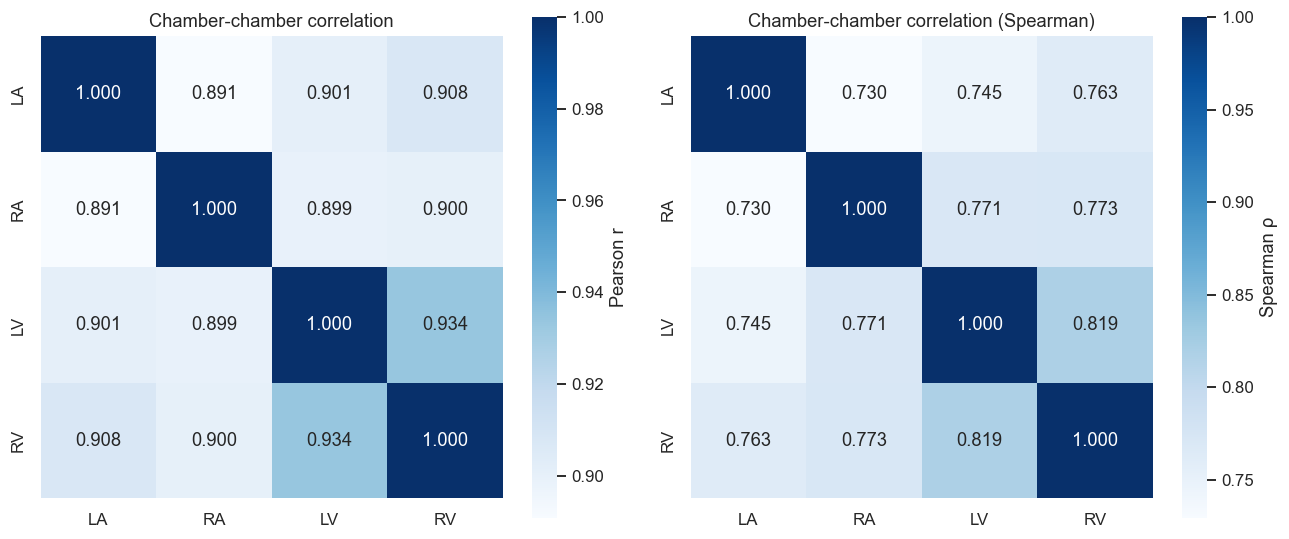

In [69]:
#calculating both cirrelations
corr_pearson = chamber_means.corr(method="pearson")
corr_spearman = chamber_means.corr(method="spearman")

#creating figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#creating pearson heatmap
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr.values.min(), vmax=1.0,
            cbar_kws={"label": "Pearson r"}, ax=ax1)
ax1.set(title="Chamber-chamber correlation")

#creating spearman heatmap
sns.heatmap(corr_spearman, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr_spearman.values.min(), vmax=1.0,
            cbar_kws={"label": "Spearman ρ"}, ax=ax2)
ax2.set(title="Chamber-chamber correlation (Spearman)")

plt.tight_layout()
plt.show()

The expression of gene is a continuous variable instead of being categorical. Spearman method is to correlate categorical variables and the slight changes in value would mean that it does not measure the correlation between a contnuos variable correctly. hence, pearson is the ideal choice for such case.

#### Exercise 3
Find genes that are higher in atria (LA+RA) vs ventricles (LV+RV).


In [70]:
# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by difference (most biased)
top_genes = delta.nlargest(10).index  #positive delta means higher in atria, negative means higher in ventricles

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYH6            5.193
NPPA            3.916
PAM             3.689
LOC101928304    3.487
NPPB            3.335
LOC101929733    3.184
TAGLN           2.871
CAV1            2.743
TBX5            2.550
DKK3            2.511
dtype: float64


In [71]:
# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by difference (most biased)
top_genes = delta.nsmallest(10).index  #positive delta means higher in atria, negative means higher in ventricles

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYL2   -3.221
HBB    -2.894
HBG1   -2.718
LYZ    -2.674
MYH7   -2.660
HBM    -2.631
DLK1   -2.506
AHSP   -2.501
HBA1   -2.354
HBG2   -2.341
dtype: float64


In [72]:
#we can also compared the genes that aree highest in both atria and ventrices using absoute value of the difference which will 
# compare the genes that are highest in both atria and ventricles regardless of which chamber they are higher in.

# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by absolute difference (most biased)
top_genes = delta.abs().nlargest(10).index

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYH6            5.193
NPPA            3.916
PAM             3.689
LOC101928304    3.487
NPPB            3.335
MYL2           -3.221
LOC101929733    3.184
HBB            -2.894
TAGLN           2.871
CAV1            2.743
dtype: float64


### Exercise 4
Repeat the single-gene analysis (plot + stats) for a different congenital heart disease gene.

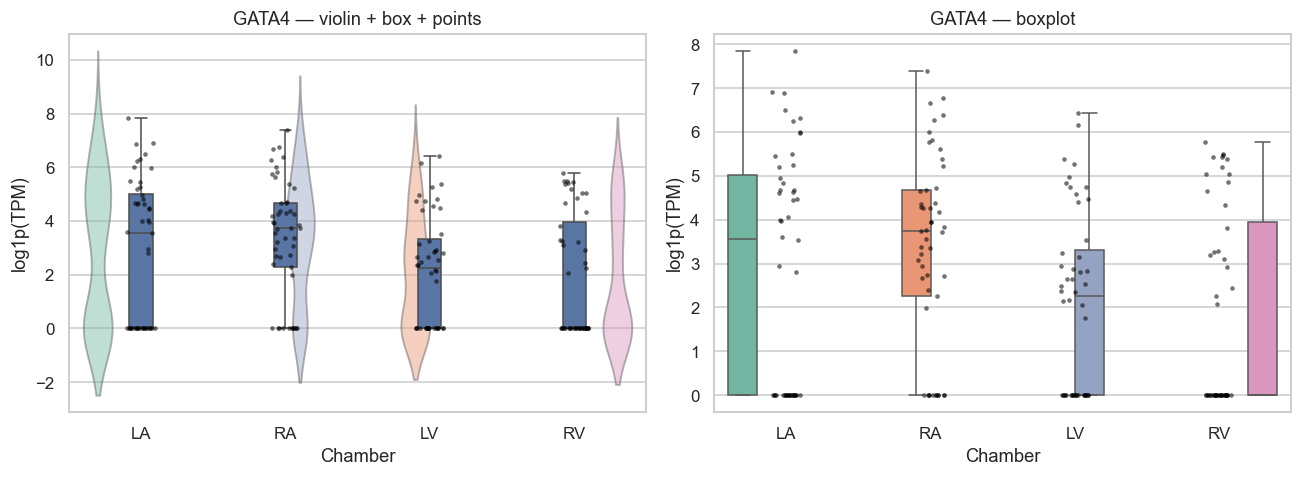

         count   mean    std  min   25%    50%    75%    max
chamber                                                     
LA        48.0  2.841  2.697  0.0  0.00  3.572  5.019  7.849
RA        49.0  3.356  2.188  0.0  2.27  3.745  4.670  7.399
LV        48.0  2.096  2.059  0.0  0.00  2.268  3.316  6.437
RV        48.0  1.845  2.262  0.0  0.00  0.000  3.946  5.776


In [73]:
GENE = "GATA4"
assert GENE in log_tpm.index, f"{GENE} not found"

# Create gene dataframe
gene_df = meta.copy()
gene_df["expression"] = log_tpm.loc[GENE]

# Plot: Violin + box + strip
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.violinplot(data=gene_df, x="chamber", y="expression", hue="chamber",
               order=CHAMBERS, palette=PALETTE, legend=False, inner=None, alpha=0.45, ax=axes[0])
sns.boxplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, width=0.16, showfliers=False, boxprops={"zorder": 2}, ax=axes[0])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, color="black", size=3, alpha=0.55, ax=axes[0])
axes[0].set(title=f"{GENE} — violin + box + points", xlabel="Chamber", ylabel="log1p(TPM)")

# Clean boxplot
sns.boxplot(data=gene_df, x="chamber", y="expression", hue="chamber", order=CHAMBERS, palette=PALETTE, legend=False, showfliers=False, ax=axes[1])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, color="black", size=3, alpha=0.55, ax=axes[1])
axes[1].set(title=f"{GENE} — boxplot", xlabel="Chamber", ylabel="log1p(TPM)")

plt.tight_layout()
plt.show()

# Summary stats
print(gene_df.groupby("chamber", observed=True)["expression"].describe().round(3))

In [74]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(CHAMBERS, 2):
    x = gene_df.loc[gene_df["chamber"] == a, "expression"]
    y = gene_df.loc[gene_df["chamber"] == b, "expression"]
    u = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({
        "group1": a, "group2": b,
        "n1": len(x), "n2": len(y),
        "median1": x.median(), "median2": y.median(),
        "U": u.statistic, "p_raw": u.pvalue,
    })

pw = pd.DataFrame(rows)
pw["p_adj"] = multipletests(pw["p_raw"], method="fdr_bh")[1]
pw["significant"] = pw["p_adj"] < 0.05
pw = pw.sort_values("p_adj").reset_index(drop=True)

print(f"pairwise comparisons of {GENE} expression (BH-corrected):")
print(pw.round(4).to_string(index=False))

pairwise comparisons of GATA4 expression (BH-corrected):
group1 group2  n1  n2  median1  median2      U  p_raw  p_adj  significant
    RA     RV  49  48   3.7455   0.0000 1583.5 0.0025 0.0147         True
    RA     LV  49  48   3.7455   2.2676 1558.0 0.0051 0.0154         True
    LA     RV  48  48   3.5724   0.0000 1382.5 0.0716 0.1432        False
    LA     LV  48  48   3.5724   2.2676 1340.0 0.1525 0.2287        False
    LA     RA  48  49   3.5724   3.7455 1096.5 0.5616 0.5771        False
    LV     RV  48  48   2.2676   0.0000 1224.0 0.5771 0.5771        False


### Exercise 5
Remove ribosomal genes and re-do the top genes.
Check for mitochondrial (MT-) genes


In [75]:
top10 = log_tpm.mean(axis=1).nlargest(10)
print("top 10 genes by mean expression:")
print(top10.round(3))

top 10 genes by mean expression:
Gene
MYL7      9.352
FTH1      8.652
ACTC1     8.520
EEF1A1    8.471
TPM1      8.431
MYL6      8.309
RPLP1     8.271
GAPDH     8.250
TMSB10    8.194
HSPB1     8.181
dtype: float64


In [78]:
#Step 1 - removing ribosomal genes
# Filter out genes starting with RPL or RPS
ribosomal = expr_f.index.str.startswith(("RPL", "RPS"))
print(f"Ribosomal genes removed: {ribosomal.sum()}")

# Keep only non-ribosomal genes
expr_filtered = expr_f[~ribosomal]

# Recalculate chamber means
chamber_means_filtered = expr_filtered.T.join(meta["chamber"]).groupby("chamber", observed=True).mean().T
chamber_means_filtered = chamber_means_filtered[CHAMBERS]
chamber_means_filtered.index.name = "Gene"

# Find top 10 genes by mean expression
top10_filtered = chamber_means_filtered.mean(axis=1).nlargest(10)
print("Top 10 genes (after removing ribosomal):")
print(top10_filtered.round(3))

Ribosomal genes removed: 114
Top 10 genes (after removing ribosomal):
Gene
HBG2      31844.072
MYL7      27051.050
HBA2      22551.048
MALAT1    13387.572
ACTC1     11003.806
TPM1      10218.101
FTH1       8351.690
NPPA       8197.039
HBG1       8067.392
TNNC1      7327.631
dtype: float64


In [79]:
# Step 2 - counting mitochondrial genes
# Count genes starting with MT- (mitochondrial)
mt_genes = expr_f.index.str.startswith("MT-")
print(f"Genes starting with MT-: {mt_genes.sum()}")

# Show them
print("\nMT- genes:")
print(expr_f.index[mt_genes].tolist())

Genes starting with MT-: 0

MT- genes:
[]


## 12. Session information

In [ ]:
import sys

try:
    import session_info

    session_info.show()
except ModuleNotFoundError:
    # Not an error in your code: this kernel simply does not have session-info.
    # It ships with the course environment (setup/python/environment.yml).
    # The interpreter path below is the fastest way to see which Python the
    # notebook is actually using, which is usually the real problem.
    print("session-info is not installed in this kernel.")
    print("kernel:", sys.executable)
    print("See setup/python/README.md to select the ZebraQ environment.")